In [1]:
# difference between KMeans and DBScan and its uses

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# load mpg dataset
data = sns.load_dataset('mpg')
data.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [4]:
data = data.dropna()

In [16]:
data = data[['cylinders','displacement','horsepower','weight','acceleration']]
data

,cylinders,displacement,horsepower,weight,acceleration
0,8,307.0,130.0,3504,12.0
1,8,350.0,165.0,3693,11.5
2,8,318.0,150.0,3436,11.0
3,8,304.0,150.0,3433,12.0
4,8,302.0,140.0,3449,10.5
...,...,...,...,...,...
393,4,140.0,86.0,2790,15.6
394,4,97.0,52.0,2130,24.6
395,4,135.0,84.0,2295,11.6
396,4,120.0,79.0,2625,18.6


In [17]:
data.isna().sum()

cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
dtype: int64

In [18]:
# scaled the data
from sklearn.preprocessing import MinMaxScaler

In [19]:
scaler = MinMaxScaler()

In [20]:
data_scaled = scaler.fit_transform(data)

In [21]:
data_scaled = pd.DataFrame(data_scaled, columns=data.columns)
data_scaled

,cylinders,displacement,horsepower,weight,acceleration
0,1.0,0.617571,0.456522,0.536150,0.238095
1,1.0,0.728682,0.646739,0.589736,0.208333
2,1.0,0.645995,0.565217,0.516870,0.178571
3,1.0,0.609819,0.565217,0.516019,0.238095
4,1.0,0.604651,0.510870,0.520556,0.148810
...,...,...,...,...,...
387,0.2,0.186047,0.217391,0.333711,0.452381
388,0.2,0.074935,0.032609,0.146583,0.988095
389,0.2,0.173127,0.206522,0.193365,0.214286
390,0.2,0.134367,0.179348,0.286929,0.630952


In [23]:
# convert data into 2D using PCA (Principle Composition Analysis)
from sklearn.decomposition import PCA

In [24]:
pca = PCA(n_components=2)

In [26]:
pca_df = pca.fit_transform(data_scaled)
pca_df

array([[ 6.17213583e-01, -6.01814453e-02],
       [ 7.71073334e-01, -1.32589783e-01],
       [ 6.73646884e-01, -1.53373805e-01],
       [ 6.44344658e-01, -1.03978179e-01],
       [ 6.39947233e-01, -1.61541653e-01],
       [ 1.03459674e+00, -2.13903891e-01],
       [ 1.12310157e+00, -3.02910024e-01],
       [ 1.09520737e+00, -3.24353214e-01],
       [ 1.13227174e+00, -2.55416483e-01],
       [ 9.24103622e-01, -3.17906006e-01],
       [ 8.24116795e-01, -2.24314669e-01],
       [ 7.75449633e-01, -3.11556389e-01],
       [ 8.36075516e-01, -1.94982876e-01],
       [ 9.68624608e-01, -3.53593647e-01],
       [-3.77880354e-01, -1.34045691e-01],
       [ 3.50190461e-02,  3.01559889e-02],
       [ 3.30792554e-02,  2.21624238e-02],
       [-1.76674388e-02,  5.73269181e-02],
       [-4.36788768e-01, -1.66632816e-01],
       [-6.20637107e-01,  2.01916599e-01],
       [-3.87835314e-01,  3.19626706e-02],
       [-3.83152290e-01, -1.46978408e-01],
       [-4.16050483e-01, -5.95712171e-03],
       [-3.

In [27]:
# array into dataframe
pca_df = pd.DataFrame(pca_df, columns=['A','B'])
pca_df

,A,B
0,0.617214,-0.060181
1,0.771073,-0.132590
2,0.673647,-0.153374
3,0.644345,-0.103978
4,0.639947,-0.161542
...,...,...
387,-0.316001,-0.051247
388,-0.616682,0.423980
389,-0.344032,-0.291173
390,-0.408270,0.102095


<Axes: title={'center': '2D representation of Data'}, xlabel='A', ylabel='B'>

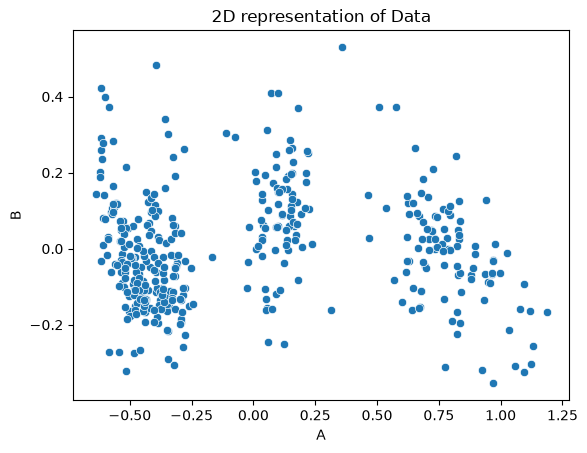

In [30]:
# plot the 2D representation of data_scaled
plt.title("2D representation of Data")
sns.scatterplot(x='A',y='B', data=pca_df)

In [32]:
# import DBScan
from sklearn.cluster import DBSCAN

In [34]:
# implement DBSCAN
# create a model of DBSCAN
dbscan = DBSCAN(eps=0.2, min_samples=5)

In [35]:
clusters = dbscan.fit_predict(pca_df)
clusters

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  0,  0,  0,  0,  1,  1,  1,  1,  1,
        1,  1,  1,  0,  0,  0,  0,  0,  0,  0,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  1,  0,  0,  0,  0,  1,  1,  1,  1,  1,  1,  1,  1,  1,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1,  1,  1,  1,  1,
        0,  0,  0,  0,  1,  1,  1,  1,  1,  1,  1,  1,  0,  0,  1,  1,  1,
        1,  0,  1,  1,  0,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  0,  0,
        0,  0,  0,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  0,  0,  0,  0,  1,  1,  1,  1,  1,  0,  0,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  0,  0,
        0,  0,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  0,  1,  1,  1,  0,  0,  0,  0,  1,  1,  1,  1,  1,  0,  0,
        0,  0,  1,  1,  1

In [36]:
pca_df['clstr'] = clusters
pca_df

,A,B,clstr
0,0.617214,-0.060181,0
1,0.771073,-0.132590,0
2,0.673647,-0.153374,0
3,0.644345,-0.103978,0
4,0.639947,-0.161542,0
...,...,...,...
387,-0.316001,-0.051247,1
388,-0.616682,0.423980,1
389,-0.344032,-0.291173,1
390,-0.408270,0.102095,1


<Axes: title={'center': '2D representation of data using DBSCAN'}, xlabel='A', ylabel='B'>

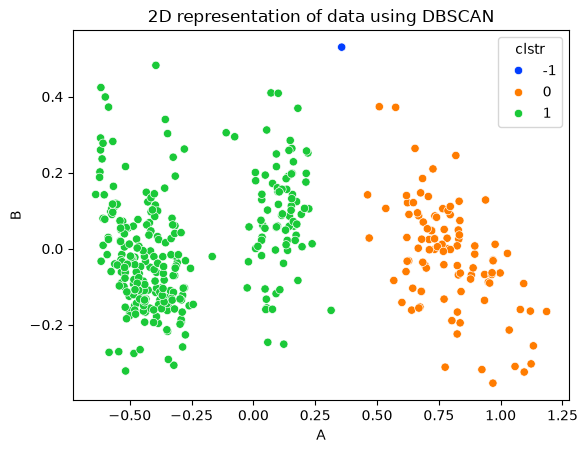

In [39]:
# plot 
plt.title("2D representation of data using DBSCAN")
sns.scatterplot(x='A',y='B', data=pca_df, hue='clstr', palette='bright')

In [40]:
# load red wine dataset
data = pd.read_csv(r"D:\my project\codeit_datascience\data_science\regression\data science\redwine_quality.csv")
data.head()

,Unnamed: 0,fixed.acidity,volatile.acidity,citric.acid,residual.sugar,chlorides,free.sulfur.dioxide,total.sulfur.dioxide,density,pH,sulphates,alcohol,quality
0,1,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,2,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,3,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,4,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,5,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [41]:
data.isna().sum()

Unnamed: 0              0
fixed.acidity           0
volatile.acidity        0
citric.acid             0
residual.sugar          0
chlorides               0
free.sulfur.dioxide     0
total.sulfur.dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [43]:
data = data.drop('Unnamed: 0', axis=1)

In [44]:
data.head()

,fixed.acidity,volatile.acidity,citric.acid,residual.sugar,chlorides,free.sulfur.dioxide,total.sulfur.dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [45]:
data.shape

(1599, 12)

In [46]:
# quality is final output / target variable
# drop 'quality'
df = data.copy()

In [47]:
data = data.drop('quality', axis=1)
data.head()

,fixed.acidity,volatile.acidity,citric.acid,residual.sugar,chlorides,free.sulfur.dioxide,total.sulfur.dioxide,density,pH,sulphates,alcohol
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4


<Axes: >

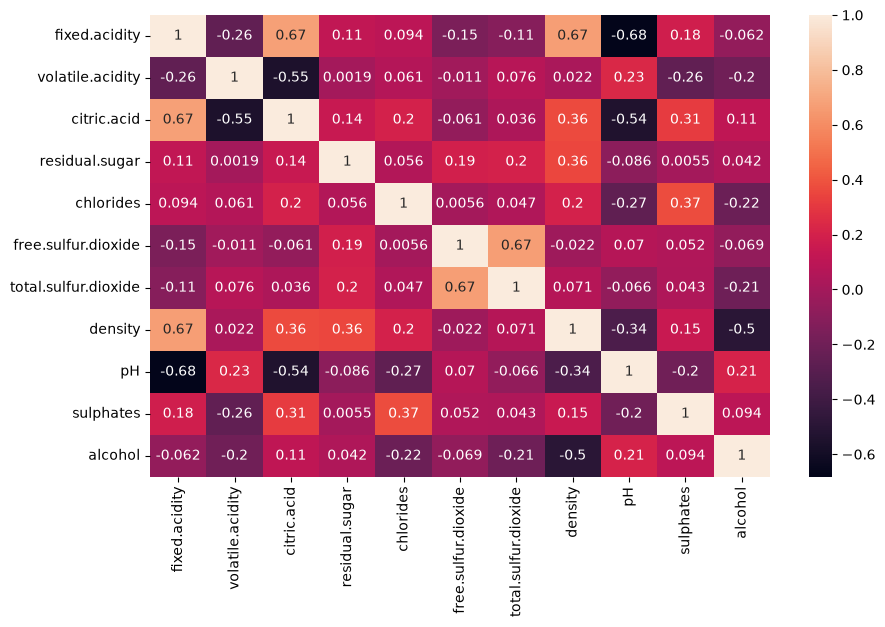

In [48]:
# check corr()
plt.figure(figsize=(10,6))
sns.heatmap(data.corr(), annot=True)

# Scaled the data by MinMaxScaler

In [49]:
scaler = MinMaxScaler()

In [50]:
scaler.fit_transform(data)

array([[0.24778761, 0.39726027, 0.        , ..., 0.60629921, 0.13772455,
        0.15384615],
       [0.28318584, 0.52054795, 0.        , ..., 0.36220472, 0.20958084,
        0.21538462],
       [0.28318584, 0.43835616, 0.04      , ..., 0.40944882, 0.19161677,
        0.21538462],
       ...,
       [0.15044248, 0.26712329, 0.13      , ..., 0.53543307, 0.25149701,
        0.4       ],
       [0.11504425, 0.35958904, 0.12      , ..., 0.65354331, 0.22754491,
        0.27692308],
       [0.12389381, 0.13013699, 0.47      , ..., 0.51181102, 0.19760479,
        0.4       ]], shape=(1599, 11))

In [51]:
data_scaled = scaler.fit_transform(data)

In [53]:
data_scaled = pd.DataFrame(data_scaled, columns=data.columns)
data_scaled

,fixed.acidity,volatile.acidity,citric.acid,residual.sugar,chlorides,free.sulfur.dioxide,total.sulfur.dioxide,density,pH,sulphates,alcohol
0,0.247788,0.397260,0.00,0.068493,0.106845,0.140845,0.098940,0.567548,0.606299,0.137725,0.153846
1,0.283186,0.520548,0.00,0.116438,0.143573,0.338028,0.215548,0.494126,0.362205,0.209581,0.215385
2,0.283186,0.438356,0.04,0.095890,0.133556,0.197183,0.169611,0.508811,0.409449,0.191617,0.215385
3,0.584071,0.109589,0.56,0.068493,0.105175,0.225352,0.190813,0.582232,0.330709,0.149701,0.215385
4,0.247788,0.397260,0.00,0.068493,0.106845,0.140845,0.098940,0.567548,0.606299,0.137725,0.153846
...,...,...,...,...,...,...,...,...,...,...,...
1594,0.141593,0.328767,0.08,0.075342,0.130217,0.436620,0.134276,0.354626,0.559055,0.149701,0.323077
1595,0.115044,0.294521,0.10,0.089041,0.083472,0.535211,0.159011,0.370778,0.614173,0.257485,0.430769
1596,0.150442,0.267123,0.13,0.095890,0.106845,0.394366,0.120141,0.416300,0.535433,0.251497,0.400000
1597,0.115044,0.359589,0.12,0.075342,0.105175,0.436620,0.134276,0.396476,0.653543,0.227545,0.276923


# Decompose the Data using PCA (principle composition analysis)

In [54]:
# decompose into 2D data set
pca_df = pca.fit_transform(data_scaled)
pca_df

array([[-0.27183851, -0.19512531],
       [-0.22584757, -0.25861705],
       [-0.18726035, -0.17995514],
       ...,
       [-0.24677055,  0.04661644],
       [-0.33806992, -0.06540783],
       [ 0.0045836 ,  0.19845025]], shape=(1599, 2))

In [55]:
pca_df = pd.DataFrame(pca_df, columns=['A','B'])
pca_df

,A,B
0,-0.271839,-0.195125
1,-0.225848,-0.258617
2,-0.187260,-0.179955
3,0.422279,-0.031881
4,-0.271839,-0.195125
...,...,...
1594,-0.337500,-0.031716
1595,-0.344092,0.038897
1596,-0.246771,0.046616
1597,-0.338070,-0.065408


# visualise the decomposed data

<Axes: title={'center': '2D representation of Redwine detaset'}, xlabel='A', ylabel='B'>

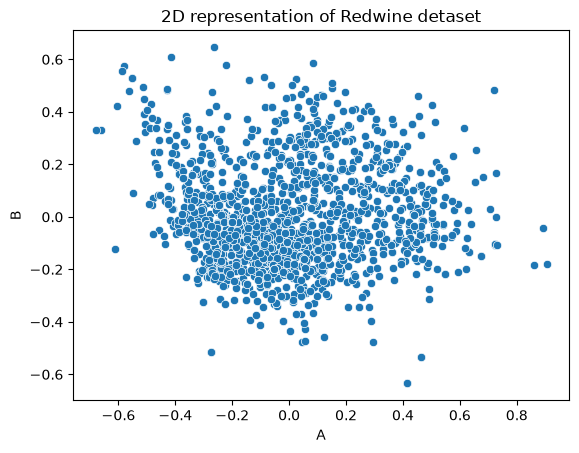

In [57]:
plt.title("2D representation of Redwine detaset")
sns.scatterplot(x='A',y='B', data=pca_df)

# KMeans Clustering

In [58]:
from sklearn.cluster import KMeans

In [59]:
wccs = []

In [60]:
for k in range(2,10):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(pca_df)
    wccs.append(kmeans.inertia_)

In [61]:
wccs

[97.28621527109884,
 69.44574508769001,
 50.53227447970032,
 39.76889144848954,
 35.33791989356949,
 30.967119734720747,
 26.43215652144319,
 23.557310222080513]

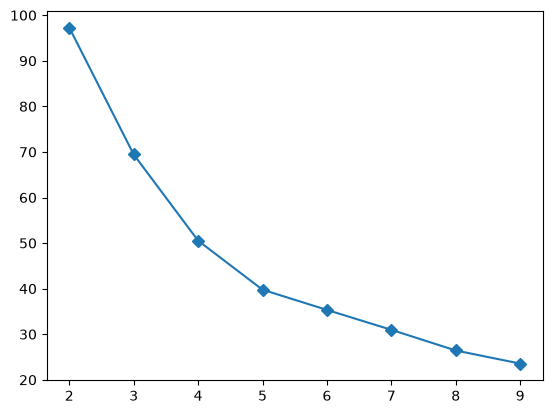

In [63]:
# plot wccs and range
plt.plot(range(2,10), wccs, marker='D')

In [65]:
# ncluster = 4
k = KMeans(n_clusters=4)
k.fit(pca_df)
pca_df['labels'] = k.labels_

In [66]:
pca_df.head()

,A,B,labels
0,-0.271839,-0.195125,0
1,-0.225848,-0.258617,0
2,-0.187260,-0.179955,0
3,0.422279,-0.031881,1
4,-0.271839,-0.195125,0


<Axes: xlabel='A', ylabel='B'>

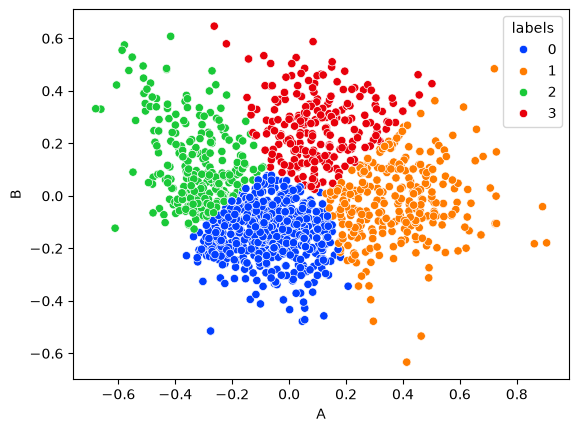

In [67]:
# plot 
sns.scatterplot(x='A',y='B', data=pca_df, hue='labels', palette='bright')

In [68]:
# nclusters=5

In [70]:
k5 = KMeans(n_clusters=5)
k5.fit(pca_df)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",5
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](5, 3)",

In [71]:
pca_df['label5'] = k5.labels_

In [72]:
pca_df

,A,B,labels,label5
0,-0.271839,-0.195125,0,1
1,-0.225848,-0.258617,0,1
2,-0.187260,-0.179955,0,1
3,0.422279,-0.031881,1,2
4,-0.271839,-0.195125,0,1
...,...,...,...,...
1594,-0.337500,-0.031716,2,0
1595,-0.344092,0.038897,2,0
1596,-0.246771,0.046616,2,0
1597,-0.338070,-0.065408,2,0


<Axes: xlabel='A', ylabel='B'>

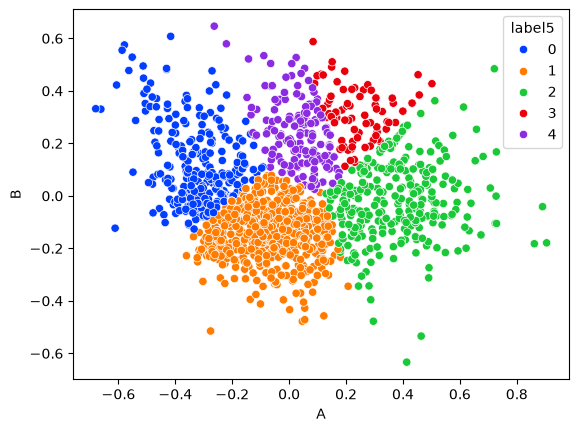

In [73]:
sns.scatterplot(x='A',y='B', data=pca_df, hue='label5', palette='bright')

C:\Users\lakpa\AppData\Local\Temp\ipykernel_21660\2397370003.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x='A',y='B', data=pca_df, ax=axes[0], palette='bright')


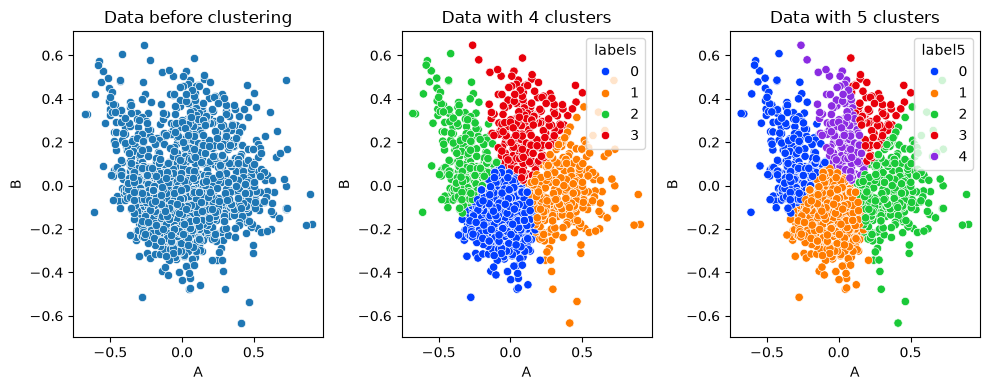

In [80]:
fig, axes = plt.subplots(1,3, figsize=(10,4))
sns.scatterplot(x='A',y='B', data=pca_df, ax=axes[0], palette='bright')
sns.scatterplot(x='A',y='B', data=pca_df, hue='labels', ax=axes[1], palette='bright')
sns.scatterplot(x='A',y='B', data=pca_df, hue='label5',ax=axes[2], palette='bright')
axes[0].set_title("Data before clustering")
axes[1].set_title("Data with 4 clusters")
axes[2].set_title("Data with 5 clusters")
plt.tight_layout()


In [81]:
pca_df

,A,B,labels,label5
0,-0.271839,-0.195125,0,1
1,-0.225848,-0.258617,0,1
2,-0.187260,-0.179955,0,1
3,0.422279,-0.031881,1,2
4,-0.271839,-0.195125,0,1
...,...,...,...,...
1594,-0.337500,-0.031716,2,0
1595,-0.344092,0.038897,2,0
1596,-0.246771,0.046616,2,0
1597,-0.338070,-0.065408,2,0


In [82]:
data.head()

,fixed.acidity,volatile.acidity,citric.acid,residual.sugar,chlorides,free.sulfur.dioxide,total.sulfur.dioxide,density,pH,sulphates,alcohol
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4


In [83]:
data['cluster4']=pca_df['labels']
data['cluster5']=pca_df['label5']

In [84]:
data.head()

,fixed.acidity,volatile.acidity,citric.acid,residual.sugar,chlorides,free.sulfur.dioxide,total.sulfur.dioxide,density,pH,sulphates,alcohol,cluster4,cluster5
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0,1
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,0,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,0,1
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,1,2
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0,1


In [88]:
data.groupby('cluster4')[['alcohol','residual.sugar']].agg(['min','max','mean'])

alcohol                  residual.sugar                
             min   max       mean            min   max      mean
cluster4                                                        
0            8.7  11.6   9.714580            1.2  13.4  2.491900
1            8.4  14.9  10.172498            1.4  15.5  2.955248
2            9.4  14.0  11.216285            1.2   8.3  2.264869
3            9.8  14.0  11.619188            0.9  12.9  2.438561

In [89]:
data.groupby('cluster5')[['alcohol','residual.sugar']].agg(['min','max','mean'])

alcohol                  residual.sugar                
             min   max       mean            min   max      mean
cluster5                                                        
0            9.4  14.0  11.216285            1.2   8.3  2.264869
1            8.7  11.6   9.714580            1.2  13.4  2.491900
2            8.4  14.9  10.172498            1.4  15.5  2.955248
3           10.4  14.0  11.883871            1.4   6.4  2.640860
4            9.8  13.6  11.480899            0.9  12.9  2.332865

<Axes: ylabel='residual.sugar'>

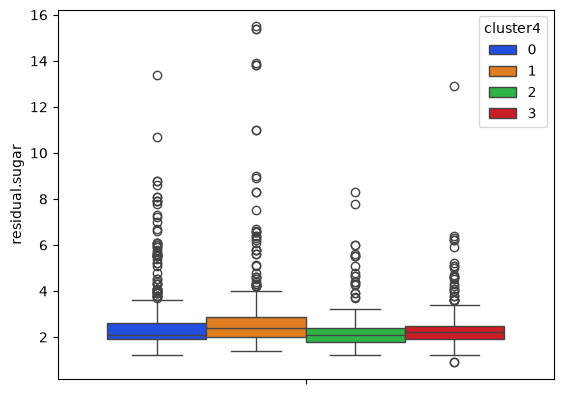

In [93]:
# check outliers
sns.boxplot(y='residual.sugar', hue='cluster4', data=data, palette='bright')

In [90]:
# use DBSCAN in above dataset and find the differences

In [95]:
dbscan = DBSCAN(eps=0.2, min_samples=5)
clusters = dbscan.fit_predict(pca_df)
clusters

array([0, 0, 0, ..., 2, 2, 3], shape=(1599,))

In [96]:
pca_df['dbscan_cls']=clusters

In [97]:
pca_df.head()

,A,B,labels,label5,dbscan_cls
0,-0.271839,-0.195125,0,1,0
1,-0.225848,-0.258617,0,1,0
2,-0.187260,-0.179955,0,1,0
3,0.422279,-0.031881,1,2,1
4,-0.271839,-0.195125,0,1,0


C:\Users\lakpa\AppData\Local\Temp\ipykernel_21660\145931449.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x='A',y='B', data=pca_df, ax=axes[0,0], palette='bright')


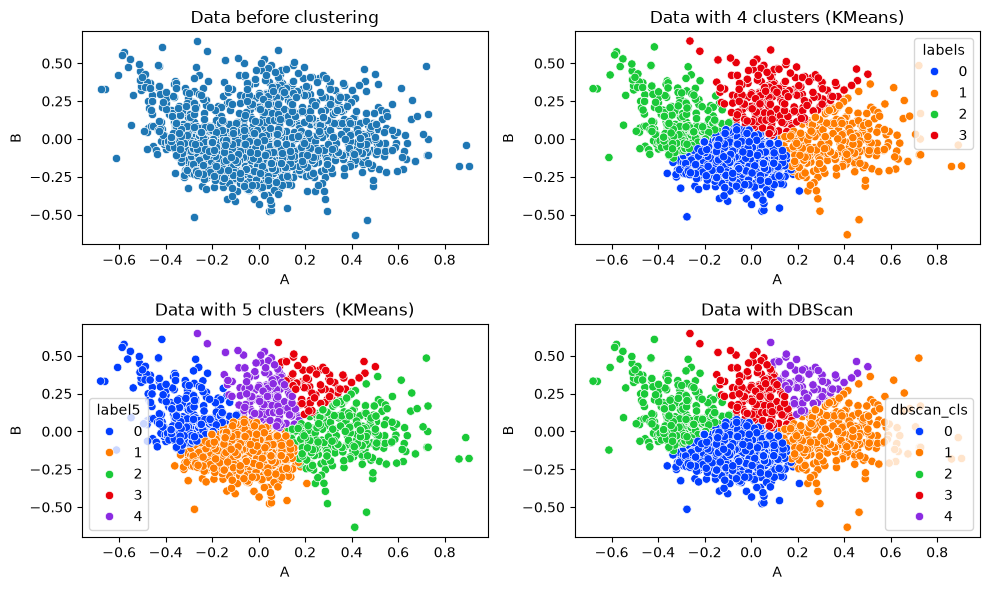

In [99]:
# plot in scatter
fig, axes = plt.subplots(2,2, figsize=(10,6))
sns.scatterplot(x='A',y='B', data=pca_df, ax=axes[0,0], palette='bright')
sns.scatterplot(x='A',y='B', data=pca_df, hue='labels', ax=axes[0,1], palette='bright')
sns.scatterplot(x='A',y='B', data=pca_df, hue='label5',ax=axes[1,0], palette='bright')
sns.scatterplot(x='A',y='B', data=pca_df, hue='dbscan_cls',ax=axes[1,1], palette='bright')
axes[0,0].set_title("Data before clustering")
axes[0,1].set_title("Data with 4 clusters (KMeans)")
axes[1,0].set_title("Data with 5 clusters  (KMeans)")
axes[1,1].set_title("Data with DBScan")
plt.tight_layout()

In [100]:
data['dbscan_cls'] = pca_df['dbscan_cls']

In [101]:
data.head()

,fixed.acidity,volatile.acidity,citric.acid,residual.sugar,chlorides,free.sulfur.dioxide,total.sulfur.dioxide,density,pH,sulphates,alcohol,cluster4,cluster5,dbscan_cls
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0,1,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,0,1,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,0,1,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,1,2,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0,1,0


In [102]:
# compare cluster4, cluster5, dbscan_cls
data.groupby('cluster4')[['alcohol','residual.sugar']].agg(['min','max','mean'])

alcohol                  residual.sugar                
             min   max       mean            min   max      mean
cluster4                                                        
0            8.7  11.6   9.714580            1.2  13.4  2.491900
1            8.4  14.9  10.172498            1.4  15.5  2.955248
2            9.4  14.0  11.216285            1.2   8.3  2.264869
3            9.8  14.0  11.619188            0.9  12.9  2.438561

In [103]:
data.groupby('cluster5')[['alcohol','residual.sugar']].agg(['min','max','mean'])

alcohol                  residual.sugar                
             min   max       mean            min   max      mean
cluster5                                                        
0            9.4  14.0  11.216285            1.2   8.3  2.264869
1            8.7  11.6   9.714580            1.2  13.4  2.491900
2            8.4  14.9  10.172498            1.4  15.5  2.955248
3           10.4  14.0  11.883871            1.4   6.4  2.640860
4            9.8  13.6  11.480899            0.9  12.9  2.332865

In [104]:
data.groupby('dbscan_cls')[['alcohol','residual.sugar']].agg(['min','max','mean'])

alcohol                  residual.sugar                
               min   max       mean            min   max      mean
dbscan_cls                                                        
0              8.7  11.6   9.714580            1.2  13.4  2.491900
1              8.4  14.9  10.172498            1.4  15.5  2.955248
2              9.4  14.0  11.216285            1.2   8.3  2.264869
3              9.8  13.6  11.480899            0.9  12.9  2.332865
4             10.4  14.0  11.883871            1.4   6.4  2.640860